In [ ]:
RGB Brightness

In [ ]:
# ============================================================
# RGB Brightness Enhancement via 2x2 Reversible Vedic Multiplier
# + PSNR / SSIM Evaluation
# ============================================================

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import math

# -------------------------------------------------
# 1) 2x2 Reversible Vedic Multiplier Gate
# -------------------------------------------------
def vedic2x2_gate():
    qc = QuantumCircuit(11, name="Vedic2x2")

    qc.cx(0, 2)
    qc.ccx(3, 2, 0)
    qc.cx(0, 1)

    qc.cx(2, 5)
    qc.ccx(5, 4, 2)
    qc.cx(2, 5)

    qc.cx(7, 3)
    qc.ccx(6, 3, 7)
    qc.cx(7, 3)
    qc.cx(6, 3)
    qc.cx(8, 4)
    qc.ccx(6, 4, 8)
    qc.cx(8, 4)
    qc.cx(6, 4)

    qc.cx(9, 1)
    qc.ccx(8, 1, 9)
    qc.cx(8, 1)
    qc.cx(8, 10)
    qc.cx(9, 5)

    return qc.to_gate(label="Vedic2x2")

vedic2 = vedic2x2_gate()

A0_Q, A1_Q = 2, 6
B0_Q, B1_Q = 3, 4
P0_Q, P1_Q, P2_Q, P3_Q = 7, 1, 5, 9

# -------------------------------------------------
# 2) Quantum-inspired multiplier wrapper
# -------------------------------------------------
def vedic_scale_2bit(value, K):
    qc = QuantumCircuit(11)

    if value & 1: qc.x(A0_Q)
    if value & 2: qc.x(A1_Q)
    if K & 1: qc.x(B0_Q)
    if K & 2: qc.x(B1_Q)

    qc.append(vedic2, range(11))
    sv = Statevector.from_instruction(qc)
    key = max(sv.probabilities_dict(), key=sv.probabilities_dict().get)

    bits = list(key)[::-1]
    p0 = int(bits[P0_Q])
    p1 = int(bits[P1_Q])
    p2 = int(bits[P2_Q])
    p3 = int(bits[P3_Q])

    return p0 | (p1 << 1) | (p2 << 2) | (p3 << 3)

# -------------------------------------------------
# 3) Quantization helpers
# -------------------------------------------------
def quantize_to_2bit(arr):
    return (arr.astype(np.uint16) * 4 // 256).astype(np.uint8)

def dequantize_from_2bit(arr):
    return (arr * (255 // 3)).astype(np.uint8)

# -------------------------------------------------
# 4) Brightness Enhancement (ADD intensity)
# -------------------------------------------------
def vedic_brightness_scale_channel(q_channel, K):
    h, w = q_channel.shape
    out = np.zeros_like(q_channel)

    for y in range(h):
        for x in range(w):
            v = int(q_channel[y, x])

            if v == 0:
                out[y, x] = 0
                continue

            prod = vedic_scale_2bit(v, K)
            out[y, x] = min(3, prod)  # clamp to 2-bit

    return out

# -------------------------------------------------
# 5) PSNR
# -------------------------------------------------
def compute_psnr(img1, img2):
    mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)
    if mse == 0:
        return float("inf")
    return 10 * math.log10((255 ** 2) / mse)

# -------------------------------------------------
# 6) SSIM (global)
# -------------------------------------------------
def compute_ssim(img1, img2):
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)

    mu1, mu2 = img1.mean(), img2.mean()
    sigma1, sigma2 = img1.var(), img2.var()
    sigma12 = ((img1 - mu1) * (img2 - mu2)).mean()

    C1 = (0.01 * 255) ** 2
    C2 = (0.03 * 255) ** 2

    return ((2 * mu1 * mu2 + C1) * (2 * sigma12 + C2)) / \
           ((mu1**2 + mu2**2 + C1) * (sigma1 + sigma2 + C2))

# -------------------------------------------------
# 7) Process RGB Brightness
# -------------------------------------------------
def process_brightness(img_path, K=2, size=(128, 128)):
    img = Image.open(img_path).convert("RGB").resize(size)
    arr = np.array(img)

    rq, gq, bq = map(quantize_to_2bit, (arr[:,:,0], arr[:,:,1], arr[:,:,2]))

    rq2 = vedic_brightness_scale_channel(rq, K)
    gq2 = vedic_brightness_scale_channel(gq, K)
    bq2 = vedic_brightness_scale_channel(bq, K)

    out = np.stack([
        dequantize_from_2bit(rq2),
        dequantize_from_2bit(gq2),
        dequantize_from_2bit(bq2)
    ], axis=2)

    out_img = Image.fromarray(out, "RGB")
    out_img.save(f"vedic_brightness_K{K}.png")

    psnr = compute_psnr(arr, out)
    ssim = compute_ssim(arr, out)

    return img, out_img, psnr, ssim

# -------------------------------------------------
# 8) MAIN
# -------------------------------------------------
if __name__ == "__main__":
    INPUT_IMAGE = "peppers.png"

    print("\nRGB Brightness Enhancement Metrics")
    print("----------------------------------")
    print("K\tPSNR (dB)\tSSIM")

    originals, outputs = [], []

    for K in (1, 2, 3):
        orig, out, psnr, ssim = process_brightness(INPUT_IMAGE, K)
        originals.append(orig)
        outputs.append(out)
        print(f"{K}\t{psnr:.2f}\t\t{ssim:.4f}")

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 4, 1)
    plt.imshow(originals[0])
    plt.title("Original")
    plt.axis("off")

    for i, K in enumerate((1, 2, 3)):
        plt.subplot(1, 4, i + 2)
        plt.imshow(outputs[i])
        plt.title(f"Brightness K={K}")
        plt.axis("off")

    plt.tight_layout()
  


In [ ]:
RGB Contrast

In [ ]:
# ============================================================
# Contrast Enhancement via 2x2 Reversible Vedic Multiplier
# (Quantum-inspired, LUT-based arithmetic)
#
# Requirements:
#   pip install qiskit pillow matplotlib numpy
#
# Output:
#   vedic_contrast_K1.png
#   vedic_contrast_K2.png
#   vedic_contrast_K3.png
# ============================================================

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os

# -------------------------------------------------
# 1) 2x2 Reversible Vedic Multiplier Gate (UNCHANGED)
# -------------------------------------------------
def vedic2x2_gate():
    qc = QuantumCircuit(11, name="Vedic2x2")

    qc.cx(0, 2)
    qc.ccx(3, 2, 0)
    qc.cx(0, 1)

    qc.cx(2, 5)
    qc.ccx(5, 4, 2)
    qc.cx(2, 5)

    qc.cx(7, 3)
    qc.ccx(6, 3, 7)
    qc.cx(7, 3)
    qc.cx(6, 3)
    qc.cx(8, 4)
    qc.ccx(6, 4, 8)
    qc.cx(8, 4)
    qc.cx(6, 4)

    qc.cx(9, 1)
    qc.ccx(8, 1, 9)
    qc.cx(8, 1)
    qc.cx(8, 10)
    qc.cx(9, 5)

    return qc.to_gate(label="Vedic2x2")

vedic2 = vedic2x2_gate()

# qubit mapping
A0_Q, A1_Q = 2, 6
B0_Q, B1_Q = 3, 4
P0_Q, P1_Q, P2_Q, P3_Q = 7, 1, 5, 9

# -------------------------------------------------
# 2) Vedic multiplier wrapper (classical control)
# -------------------------------------------------
def vedic_scale_2bit(value, K):
    qc = QuantumCircuit(11)

    if value & 1: qc.x(A0_Q)
    if value & 2: qc.x(A1_Q)
    if K & 1: qc.x(B0_Q)
    if K & 2: qc.x(B1_Q)

    qc.append(vedic2, range(11))
    sv = Statevector.from_instruction(qc)
    key = max(sv.probabilities_dict(), key=sv.probabilities_dict().get)

    bits = list(key)[::-1]
    p0 = int(bits[P0_Q])
    p1 = int(bits[P1_Q])
    p2 = int(bits[P2_Q])
    p3 = int(bits[P3_Q])

    return p0 | (p1 << 1) | (p2 << 2) | (p3 << 3)

# -------------------------------------------------
# 3) Quantization helpers
# -------------------------------------------------
def quantize_to_2bit(arr):
    return (arr.astype(np.uint16) * 4 // 256).astype(np.uint8)

def dequantize_from_2bit(arr):
    return (arr * (255 // 3)).astype(np.uint8)

# -------------------------------------------------
# 4) Contrast Enhancement (ONLY)
# -------------------------------------------------
def vedic_contrast_scale_channel(q_channel, K):
    h, w = q_channel.shape
    out = np.zeros_like(q_channel)
    mid = 2  # discrete midpoint for 0..3

    for y in range(h):
        for x in range(w):
            v = int(q_channel[y, x])
            delta = v - mid
            if delta == 0:
                out[y, x] = v
                continue

            sign = 1 if delta > 0 else -1
            mag = abs(delta)

            prod = vedic_scale_2bit(mag, K)
            prod = min(3, prod)

            out[y, x] = max(0, min(3, mid + sign * prod))

    return out

# -------------------------------------------------
# 5) Apply Contrast Enhancement
# -------------------------------------------------
def process_contrast(img_path, size=(128, 128), K=2):
    img = Image.open(img_path).convert("RGB")
    img = img.resize(size, Image.BILINEAR)
    arr = np.array(img)

    rq, gq, bq = map(quantize_to_2bit, (arr[:,:,0], arr[:,:,1], arr[:,:,2]))

    rq2 = vedic_contrast_scale_channel(rq, K)
    gq2 = vedic_contrast_scale_channel(gq, K)
    bq2 = vedic_contrast_scale_channel(bq, K)

    out = np.stack([
        dequantize_from_2bit(rq2),
        dequantize_from_2bit(gq2),
        dequantize_from_2bit(bq2)
    ], axis=2)

    out_img = Image.fromarray(out, "RGB")
    out_img.save(f"vedic_contrast_K{K}.png")
    return img, out_img

# -------------------------------------------------
# 6) MAIN: Horizontal Display (K=1,2,3)
# -------------------------------------------------
if __name__ == "__main__":
    INPUT_IMAGE = "peppers.png"  # change if needed

    originals = []
    outputs = []

    for K in (1, 2, 3):
        orig, out = process_contrast(INPUT_IMAGE, K=K)
        originals.append(orig)
        outputs.append(out)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 4, 1)
    plt.imshow(originals[0])
    plt.title("Original")
    plt.axis("off")

    for i, K in enumerate((1, 2, 3)):
        plt.subplot(1, 4, i + 2)
        plt.imshow(outputs[i])
        plt.title(f"Contrast K={K}")
        plt.axis("off")

    plt.tight_layout()



In [ ]:
RGB Edge Detection

In [ ]:
# Quantum RGB Edge Detection using 2×2 Vedic Multiplier (QV-LUT)
# -------------------------------------------------------------
# pip install qiskit pillow matplotlib

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1) Your 2×2 Vedic multiplier gate (UNCHANGED)
# -------------------------------------------------
def vedic2x2_gate():
    qc = QuantumCircuit(11, name="Vedic2x2")

    qc.cx(0, 2)
    qc.ccx(3, 2, 0)
    qc.cx(0, 1)

    qc.cx(2, 5)
    qc.ccx(5, 4, 2)
    qc.cx(2, 5)

    qc.cx(7, 3)
    qc.ccx(6, 3, 7)
    qc.cx(7, 3)
    qc.cx(6, 3)
    qc.cx(8, 4)
    qc.ccx(6, 4, 8)
    qc.cx(8, 4)
    qc.cx(6, 4)

    qc.cx(9, 1)
    qc.ccx(8, 1, 9)
    qc.cx(8, 1)
    qc.cx(8, 10)
    qc.cx(9, 5)

    return qc.to_gate(label="Vedic2x2")

vedic2 = vedic2x2_gate()

A0_Q, A1_Q = 2, 6
B0_Q, B1_Q = 3, 4
P0_Q, P1_Q, P2_Q, P3_Q = 7, 1, 5, 9

# -------------------------------------------------
# 2) Quantum 2-bit scaling via Vedic multiplier
# -------------------------------------------------
def vedic_scale_2bit(value, K):
    qc = QuantumCircuit(11)

    if value & 1: qc.x(A0_Q)
    if value & 2: qc.x(A1_Q)
    if K & 1: qc.x(B0_Q)
    if K & 2: qc.x(B1_Q)

    qc.append(vedic2, range(11))

    sv = Statevector.from_instruction(qc)
    bitstring = max(sv.probabilities_dict(), key=sv.probabilities_dict().get)
    bits = bitstring[::-1]

    product = (
        int(bits[P0_Q]) |
        (int(bits[P1_Q]) << 1) |
        (int(bits[P2_Q]) << 2) |
        (int(bits[P3_Q]) << 3)
    )
    return product

# -------------------------------------------------
# 3) Quantum RGB edge map (channel-wise)
# -------------------------------------------------
def quantum_rgb_edge_map_2bit(image_rgb8, K=3):
    """
    Apply BW quantum edge detector independently to R, G, B channels.
    """
    h, w, _ = image_rgb8.shape
    edge_rgb = np.zeros_like(image_rgb8, dtype=np.uint8)

    for c in range(3):  # R, G, B
        channel = image_rgb8[:, :, c].astype(np.int32)

        g_raw = np.zeros((h, w), dtype=np.int32)
        for y in range(h):
            for x in range(w):
                v = channel[y, x]
                gx = abs(channel[y, x + 1] - v) if x < w - 1 else 0
                gy = abs(channel[y + 1, x] - v) if y < h - 1 else 0
                g_raw[y, x] = gx + gy

        max_g = int(g_raw.max())
        if max_g == 0:
            continue

        edge_ch = np.zeros((h, w), dtype=np.uint8)

        for y in range(h):
            for x in range(w):
                g = int(round(3.0 * g_raw[y, x] / max_g))
                g = min(3, g)

                if g == 0:
                    continue

                e = vedic_scale_2bit(g, K)
                edge_ch[y, x] = min(3, e)

        edge_rgb[:, :, c] = (edge_ch * (255 // 3)).astype(np.uint8)

    return edge_rgb

# -------------------------------------------------
# 4) Load RGB image
# -------------------------------------------------
IMAGE_PATH = "peppers.png"
TARGET_SIZE = (128, 128)

img = Image.open(IMAGE_PATH).convert("RGB")
img = img.resize(TARGET_SIZE, Image.BILINEAR)
img_arr = np.array(img, dtype=np.uint8)

# -------------------------------------------------
# 5) Run quantum RGB edge detection for K = 1, 2, 3
# -------------------------------------------------
K_values = [1, 2, 3]
results = {}

for K in K_values:
    results[K] = quantum_rgb_edge_map_2bit(img_arr, K=K)

# -------------------------------------------------
# 6) Visualization
# -------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

axes[0].imshow(img_arr)
axes[0].set_title("Original RGB")
axes[0].axis("off")

for i, K in enumerate(K_values, start=1):
    axes[i].imshow(results[K])
    axes[i].set_title(f"RGB Edge (K={K})")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
BW Contast

In [ ]:
# ============================================================
# Contrast Enhancement via 2x2 Reversible Vedic Multiplier
# (Quantum-inspired, LUT-based arithmetic with PSNR & SSIM)
#
# Requirements:
#   pip install qiskit pillow matplotlib numpy scikit-image
#
# Outputs:
#   vedic_contrast_K1.png
#   vedic_contrast_K2.png
#   vedic_contrast_K3.png
# ============================================================

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# -------------------------------------------------
# 1) 2x2 Reversible Vedic Multiplier Gate (UNCHANGED)
# -------------------------------------------------
def vedic2x2_gate():
    qc = QuantumCircuit(11, name="Vedic2x2")

    qc.cx(0, 2)
    qc.ccx(3, 2, 0)
    qc.cx(0, 1)

    qc.cx(2, 5)
    qc.ccx(5, 4, 2)
    qc.cx(2, 5)

    qc.cx(7, 3)
    qc.ccx(6, 3, 7)
    qc.cx(7, 3)
    qc.cx(6, 3)

    qc.cx(8, 4)
    qc.ccx(6, 4, 8)
    qc.cx(8, 4)
    qc.cx(6, 4)

    qc.cx(9, 1)
    qc.ccx(8, 1, 9)
    qc.cx(8, 1)
    qc.cx(8, 10)
    qc.cx(9, 5)

    return qc.to_gate(label="Vedic2x2")

vedic2 = vedic2x2_gate()

# Qubit mapping
A0_Q, A1_Q = 2, 6
B0_Q, B1_Q = 3, 4
P0_Q, P1_Q, P2_Q, P3_Q = 7, 1, 5, 9

# -------------------------------------------------
# 2) Vedic Multiplier Wrapper (Classical Control)
# -------------------------------------------------
def vedic_scale_2bit(value, K):
    qc = QuantumCircuit(11)

    if value & 1: qc.x(A0_Q)
    if value & 2: qc.x(A1_Q)
    if K & 1: qc.x(B0_Q)
    if K & 2: qc.x(B1_Q)

    qc.append(vedic2, range(11))
    sv = Statevector.from_instruction(qc)
    key = max(sv.probabilities_dict(), key=sv.probabilities_dict().get)

    bits = list(key)[::-1]
    p0 = int(bits[P0_Q])
    p1 = int(bits[P1_Q])
    p2 = int(bits[P2_Q])
    p3 = int(bits[P3_Q])

    return p0 | (p1 << 1) | (p2 << 2) | (p3 << 3)

# -------------------------------------------------
# 3) Quantization Helpers
# -------------------------------------------------
def quantize_to_2bit(arr):
    return (arr.astype(np.uint16) * 4 // 256).astype(np.uint8)

def dequantize_from_2bit(arr):
    return (arr * (255 // 3)).astype(np.uint8)

# -------------------------------------------------
# 4) Contrast Enhancement Core
# -------------------------------------------------
def vedic_contrast_scale_channel(q_channel, K):
    h, w = q_channel.shape
    out = np.zeros_like(q_channel)
    mid = 2  # midpoint of {0,1,2,3}

    for y in range(h):
        for x in range(w):
            v = int(q_channel[y, x])
            delta = v - mid

            if delta == 0:
                out[y, x] = v
                continue

            sign = 1 if delta > 0 else -1
            mag = abs(delta)

            prod = vedic_scale_2bit(mag, K)
            prod = min(3, prod)

            out[y, x] = max(0, min(3, mid + sign * prod))

    return out

# -------------------------------------------------
# 5) Image Processing Pipeline
# -------------------------------------------------
def process_contrast(img_path, size=(128, 128), K=2):
    img = Image.open(img_path).convert("RGB")
    img = img.resize(size, Image.BILINEAR)
    arr = np.array(img)

    rq, gq, bq = map(quantize_to_2bit,
                     (arr[:,:,0], arr[:,:,1], arr[:,:,2]))

    rq2 = vedic_contrast_scale_channel(rq, K)
    gq2 = vedic_contrast_scale_channel(gq, K)
    bq2 = vedic_contrast_scale_channel(bq, K)

    out = np.stack([
        dequantize_from_2bit(rq2),
        dequantize_from_2bit(gq2),
        dequantize_from_2bit(bq2)
    ], axis=2)

    out_img = Image.fromarray(out, "RGB")
    out_img.save(f"vedic_contrast_K{K}.png")

    return img, out_img

# -------------------------------------------------
# 6) PSNR & SSIM Computation
# -------------------------------------------------
def compute_psnr_ssim(ref_img, test_img):
    ref = np.array(ref_img).astype(np.uint8)
    test = np.array(test_img).astype(np.uint8)

    psnr = peak_signal_noise_ratio(ref, test, data_range=255)

    ref_gray = np.array(ref_img.convert("L"))
    test_gray = np.array(test_img.convert("L"))

    ssim = structural_similarity(ref_gray, test_gray, data_range=255)

    return psnr, ssim

# -------------------------------------------------
# 7) MAIN
# -------------------------------------------------
if __name__ == "__main__":

    INPUT_IMAGE = "cameraman.png"  # change if needed

    originals = []
    outputs = []

    print("\nQuantitative Image Quality Metrics")
    print("---------------------------------")
    print("K\tPSNR (dB)\tSSIM")

    for K in (1, 2, 3):
        orig, out = process_contrast(INPUT_IMAGE, K=K)
        originals.append(orig)
        outputs.append(out)

        psnr, ssim = compute_psnr_ssim(orig, out)
        print(f"{K}\t{psnr:.2f}\t\t{ssim:.4f}")

    # Visualization
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(originals[0])
    plt.title("Original")
    plt.axis("off")

    for i, K in enumerate((1, 2, 3)):
        plt.subplot(1, 4, i + 2)
        plt.imshow(outputs[i])
        plt.title(f"Contrast K={K}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


In [ ]:
BW Brightness

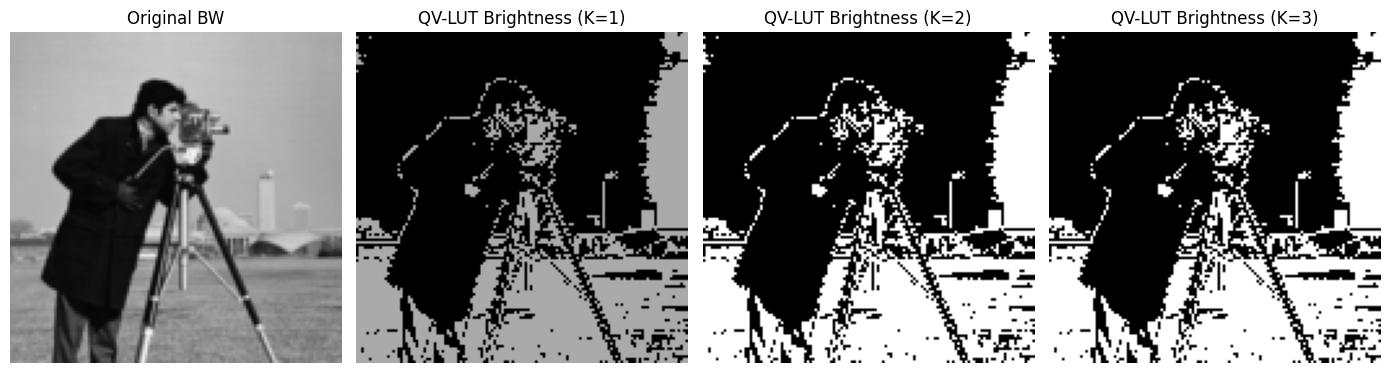

In [1]:
# ============================================================
# Brightness Enhancement via 2x2 Reversible Vedic Multiplier
# (Quantum-inspired, LUT-based arithmetic with PSNR & SSIM)
#
# Outputs:
#   vedic_brightness_K1.png
#   vedic_brightness_K2.png
#   vedic_brightness_K3.png
# ============================================================

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# -------------------------------------------------
# 1) 2x2 Reversible Vedic Multiplier Gate
# -------------------------------------------------
def vedic2x2_gate():
    qc = QuantumCircuit(11, name="Vedic2x2")

    qc.cx(0, 2)
    qc.ccx(3, 2, 0)
    qc.cx(0, 1)

    qc.cx(2, 5)
    qc.ccx(5, 4, 2)
    qc.cx(2, 5)

    qc.cx(7, 3)
    qc.ccx(6, 3, 7)
    qc.cx(7, 3)
    qc.cx(6, 3)

    qc.cx(8, 4)
    qc.ccx(6, 4, 8)
    qc.cx(8, 4)
    qc.cx(6, 4)

    qc.cx(9, 1)
    qc.ccx(8, 1, 9)
    qc.cx(8, 1)
    qc.cx(8, 10)
    qc.cx(9, 5)

    return qc.to_gate(label="Vedic2x2")

vedic2 = vedic2x2_gate()

# Qubit mapping
A0_Q, A1_Q = 2, 6
B0_Q, B1_Q = 3, 4
P0_Q, P1_Q, P2_Q, P3_Q = 7, 1, 5, 9

# -------------------------------------------------
# 2) Vedic Multiplier Wrapper
# -------------------------------------------------
def vedic_scale_2bit(value, K):
    qc = QuantumCircuit(11)

    if value & 1: qc.x(A0_Q)
    if value & 2: qc.x(A1_Q)
    if K & 1: qc.x(B0_Q)
    if K & 2: qc.x(B1_Q)

    qc.append(vedic2, range(11))
    sv = Statevector.from_instruction(qc)
    key = max(sv.probabilities_dict(), key=sv.probabilities_dict().get)

    bits = list(key)[::-1]
    p0 = int(bits[P0_Q])
    p1 = int(bits[P1_Q])
    p2 = int(bits[P2_Q])
    p3 = int(bits[P3_Q])

    return p0 | (p1 << 1) | (p2 << 2) | (p3 << 3)

# -------------------------------------------------
# 3) Quantization
# -------------------------------------------------
def quantize_to_2bit(arr):
    return (arr.astype(np.uint16) * 4 // 256).astype(np.uint8)

def dequantize_from_2bit(arr):
    return (arr * (255 // 3)).astype(np.uint8)

# -------------------------------------------------
# 4) Brightness Enhancement Core
# -------------------------------------------------
def vedic_brightness_channel(q_channel, K):
    """
    Brightness formula:
        I_out = I_in + (I_in * K_small)

    Uses Vedic multiplier to scale brightness increment.
    """

    h, w = q_channel.shape
    out = np.zeros_like(q_channel)

    for y in range(h):
        for x in range(w):
            v = int(q_channel[y, x])

            # Multiply intensity by small K (1–3)
            increment = vedic_scale_2bit(v, K)

            # Scale down increment to fit 2-bit range
            increment = increment // 2

            new_val = v + increment
            out[y, x] = min(3, new_val)

    return out

# -------------------------------------------------
# 5) Image Processing Pipeline
# -------------------------------------------------
def process_brightness(img_path, size=(128, 128), K=1):
    img = Image.open(img_path).convert("RGB")
    img = img.resize(size, Image.BILINEAR)
    arr = np.array(img)

    rq, gq, bq = map(quantize_to_2bit,
                     (arr[:,:,0], arr[:,:,1], arr[:,:,2]))

    rq2 = vedic_brightness_channel(rq, K)
    gq2 = vedic_brightness_channel(gq, K)
    bq2 = vedic_brightness_channel(bq, K)

    out = np.stack([
        dequantize_from_2bit(rq2),
        dequantize_from_2bit(gq2),
        dequantize_from_2bit(bq2)
    ], axis=2)

    out_img = Image.fromarray(out, "RGB")
    out_img.save(f"vedic_brightness_K{K}.png")

    return img, out_img

# -------------------------------------------------
# 6) PSNR & SSIM
# -------------------------------------------------
def compute_psnr_ssim(ref_img, test_img):
    ref = np.array(ref_img).astype(np.uint8)
    test = np.array(test_img).astype(np.uint8)

    psnr = peak_signal_noise_ratio(ref, test, data_range=255)

    ref_gray = np.array(ref_img.convert("L"))
    test_gray = np.array(test_img.convert("L"))

    ssim = structural_similarity(ref_gray, test_gray, data_range=255)

    return psnr, ssim

# -------------------------------------------------
# 7) MAIN
# -------------------------------------------------
if __name__ == "__main__":

    INPUT_IMAGE = "cameraman.png"

    print("\nBrightness Enhancement Metrics")
    print("--------------------------------")
    print("K\tPSNR (dB)\tSSIM")

    originals = []
    outputs = []

    for K in (1, 2, 3):
        orig, out = process_brightness(INPUT_IMAGE, K=K)
        originals.append(orig)
        outputs.append(out)

        psnr, ssim = compute_psnr_ssim(orig, out)
        print(f"{K}\t{psnr:.2f}\t\t{ssim:.4f}")

    # Visualization
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(originals[0])
    plt.title("Original")
    plt.axis("off")

    for i, K in enumerate((1, 2, 3)):
        plt.subplot(1, 4, i + 2)
        plt.imshow(outputs[i])
        plt.title(f"Brightness K={K}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
BW Edge detection 

In [ ]:
# Improved Quantum Edge Detection using 2×2 Vedic Multiplier
# ---------------------------------------------------------
# pip install qiskit pillow matplotlib scikit-image

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import math
from skimage.metrics import structural_similarity as ssim

# -------------------------------------------------
# 1) 2×2 Vedic Multiplier Gate (11 qubits)
# -------------------------------------------------
def vedic2x2_gate():
    qc = QuantumCircuit(11, name="Vedic2x2")

    # N1 block
    qc.cx(0, 2)
    qc.ccx(3, 2, 0)
    qc.cx(0, 1)

    # RF block
    qc.cx(2, 5)
    qc.ccx(5, 4, 2)
    qc.cx(2, 5)

    # A block
    qc.cx(7, 3)
    qc.ccx(6, 3, 7)
    qc.cx(7, 3)
    qc.cx(6, 3)
    qc.cx(8, 4)
    qc.ccx(6, 4, 8)
    qc.cx(8, 4)
    qc.cx(6, 4)

    # N3 block
    qc.cx(9, 1)
    qc.ccx(8, 1, 9)
    qc.cx(8, 1)
    qc.cx(8, 10)
    qc.cx(9, 5)

    return qc.to_gate(label="Vedic2x2")

vedic2 = vedic2x2_gate()

# Qubit indices
A0_Q, A1_Q = 2, 6
B0_Q, B1_Q = 3, 4
P0_Q, P1_Q, P2_Q, P3_Q = 7, 1, 5, 9

# -------------------------------------------------
# 2) Quantum 2-bit scaling using Vedic multiplier
# -------------------------------------------------
def vedic_scale_2bit(value, K):
    qc = QuantumCircuit(11)

    if value & 1: qc.x(A0_Q)
    if value & 2: qc.x(A1_Q)
    if K & 1: qc.x(B0_Q)
    if K & 2: qc.x(B1_Q)

    qc.append(vedic2, range(11))

    sv = Statevector.from_instruction(qc)
    bitstring = max(sv.probabilities_dict(), key=sv.probabilities_dict().get)
    bits = bitstring[::-1]

    product = (
        int(bits[P0_Q]) |
        (int(bits[P1_Q]) << 1) |
        (int(bits[P2_Q]) << 2) |
        (int(bits[P3_Q]) << 3)
    )
    return product

# -------------------------------------------------
# 3) Quantum Edge Detection (Grayscale)
# -------------------------------------------------
def quantum_edge_map_2bit_from_gray(image_gray8, K=3):
    h, w = image_gray8.shape
    image_gray8 = image_gray8.astype(np.int32)

    g_raw = np.zeros((h, w), dtype=np.int32)

    for y in range(h):
        for x in range(w):
            v = image_gray8[y, x]
            gx = abs(image_gray8[y, x + 1] - v) if x < w - 1 else 0
            gy = abs(image_gray8[y + 1, x] - v) if y < h - 1 else 0
            g_raw[y, x] = gx + gy

    max_g = int(g_raw.max())
    if max_g == 0:
        return np.zeros((h, w), dtype=np.uint8)

    edge_map = np.zeros((h, w), dtype=np.uint8)

    for y in range(h):
        for x in range(w):
            g = int(round(3.0 * g_raw[y, x] / max_g))
            g = min(3, g)

            if g == 0:
                continue

            e = vedic_scale_2bit(g, K)
            edge_map[y, x] = min(3, e)

    return edge_map.astype(np.uint8)

# -------------------------------------------------
# 4) Load image
# -------------------------------------------------
IMAGE_PATH = "cameraman.png"   # change if needed
TARGET_SIZE = (128, 128)

img = Image.open(IMAGE_PATH).convert("L")
img = img.resize(TARGET_SIZE, Image.BILINEAR)
img_arr = np.array(img, dtype=np.uint8)

# -------------------------------------------------
# 5) Run quantum edge detection
# -------------------------------------------------
K_values = [1, 2, 3]
edge_results = {}

for K in K_values:
    edge_2bit = quantum_edge_map_2bit_from_gray(img_arr, K)
    edge_results[K] = (edge_2bit * (255 // 3)).astype(np.uint8)

# -------------------------------------------------
# 6) Visualization
# -------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(14, 3))

axes[0].imshow(img_arr, cmap='gray')
axes[0].set_title("Original")
axes[0].axis("off")

for i, K in enumerate(K_values, start=1):
    axes[i].imshow(edge_results[K], cmap='gray')
    axes[i].set_title(f"Edge (K={K})")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

# -------------------------------------------------
# 7) PSNR and SSIM
# -------------------------------------------------
def compute_psnr(img_ref, img_test):
    img_ref = img_ref.astype(np.float64)
    img_test = img_test.astype(np.float64)
    mse = np.mean((img_ref - img_test) ** 2)
    if mse == 0:
        return float("inf")
    return 20 * math.log10(255.0 / math.sqrt(mse))

def compute_ssim(img_ref, img_test):
    val, _ = ssim(img_ref, img_test, data_range=255, full=True)
    return val

# -------------------------------------------------
# 8) Print Metrics
# -------------------------------------------------
print("\n=== Improved Quantum Edge Detection: PSNR & SSIM ===")
print("K\tPSNR (dB)\tSSIM")
print("-----------------------------------")

for K in K_values:
    psnr_val = compute_psnr(img_arr, edge_results[K])
    ssim_val = compute_ssim(img_arr, edge_results[K])
    print(f"{K}\t{psnr_val:.2f}\t\t{ssim_val:.4f}")

    